In [89]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import os
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
# ─── Step 1: Load and Clean ───────────────────────────────────
df_train = pd.read_csv("Train.csv")
df_test = pd.read_csv("Test.csv")
#Data Loading and Initial Partitioning : -->The first step in the pipeline involves loading the dataset using the Pandas library. The data is imported from two separate CSV files: Train.csv and Test.csv. This separation is crucial for maintaining the integrity of the machine learning process; the Training set is utilized to fit the model and discover underlying patterns, while the Test set is reserved as an unseen benchmark to evaluate the model's final performance and generalization ability.

In [91]:
education_map = {
    "Preschool": 1, "1st-4th": 2, "5th-6th": 3, "7th-8th": 4,
    "9th": 5, "10th": 6, "11th": 7, "12th": 8, "HS-grad": 9,
    "Some-college": 10, "Assoc-voc": 11, "Assoc-acdm": 12,
    "Bachelors": 13, "Masters": 14, "Prof-school": 15, "Doctorate": 16
}
# Feature Encoding: Ordinal Mapping: -->Since machine learning models primarily work with numbers, I converted the 'Education' column from text to numeric values. I chose a manual mapping approach because educational levels follow a specific order or "rank." By assigning a higher number to more advanced degrees (like 16 for a Doctorate and 1 for Preschool), the model can easily understand the natural progression and importance of education in our dataset.

In [92]:
# Standardize column names
df_test = df_test.rename(columns={
    "workclass": "work-class",
    "fnlwgt":    "work-fnl",
    "occupation":"position"
})
# Standardizing Column Names: --> Renamed several columns in the test dataset to ensure they perfectly match the names used in the training set. This is a critical step because machine learning models expect consistent input features; even a small difference like a missing hyphen would cause an error during prediction. Additionally, renaming columns like 'occupation' to 'position' makes the dataset easier to understand and work with.

In [93]:
# Remove duplicates
df_train = df_train.drop_duplicates()
df_test  = df_test.drop_duplicates()
#Removing Duplicate Records: --> In this step, I cleaned the dataset by removing any identical rows using the drop_duplicates() function. Keeping duplicate data can negatively affect the model by causing it to give undue weight to certain patterns, leading to biased results. By ensuring each record is unique, I improve the model's efficiency and ensure that the evaluation of its performance is fair and accurate.

In [94]:
# Handle hidden nulls (' ?') then strip ALL string columns
df_train.replace(" ?", np.nan, inplace=True)
df_test.replace(" ?", np.nan, inplace=True)
df_train.dropna(inplace=True)
df_test.dropna(inplace=True)
#Handling Missing Values (Hidden Nulls): -->Real-world datasets often contain missing information represented by placeholders like questions marks (?) instead of standard null values. In this step, I replaced all occurrences of " ?" with NaN using the replace() function to make them recognizable as missing data. After identifying these hidden nulls, I used dropna() to remove those records from both the training and testing sets. This ensures that the model is trained only on complete and reliable information, preventing errors and improving overall accuracy.

✅ Strip leading/trailing spaces from every string column

In [95]:
for col in df_train.select_dtypes(include='str').columns:
    df_train[col] = df_train[col].str.strip()
for col in df_test.select_dtypes(include='str').columns:
    df_test[col] = df_test[col].str.strip()

In [96]:
# Encode target
target = "salary"
le_salary = LabelEncoder()
le_sex = LabelEncoder()
df_train["salary"] = le_salary.fit_transform(df_train["salary"])
df_test["salary"]  = le_salary.transform(df_test["salary"])

df_train["sex"] = le_sex.fit_transform(df_train["sex"])
df_test["sex"] = le_sex.transform(df_test["sex"])
#Target Variable Encoding: --> Since our target variable salary consists of categorical labels, I used LabelEncoder to convert them into a numerical format (0 and 1). I applied fit_transform on the training data to learn the mapping, and only transform on the test data to ensure consistency. This prevents "data leakage" and ensures that the model evaluates the test set using the exact same categories it learned during training.

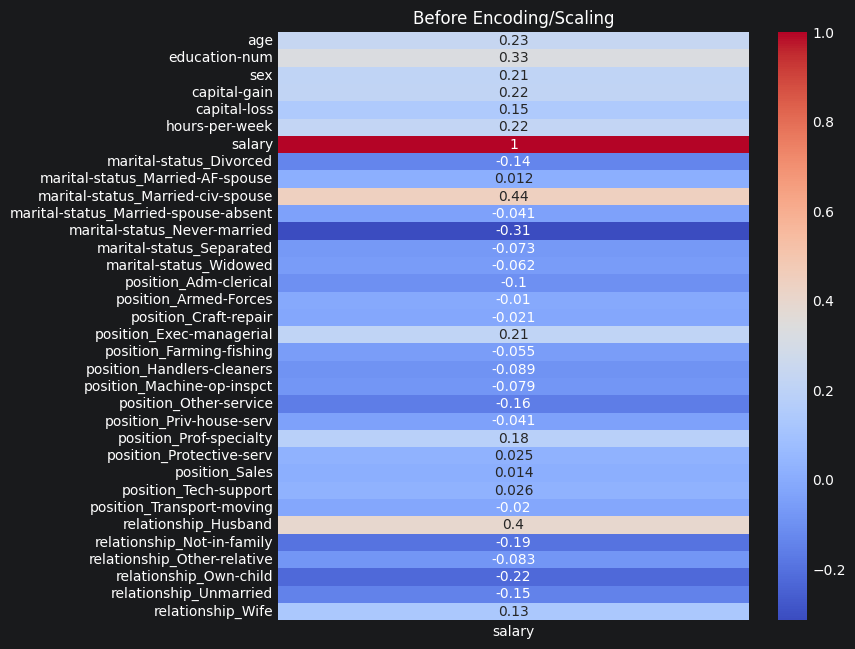

In [113]:
# showing correlation between features vs salary before correlation
df_train_before = df_train.copy()

df_train_corr = df_train_before.select_dtypes(include='number').corr()

plt.figure(figsize=(6, 6))

sns.heatmap(df_train_corr[['salary']], annot=True, cmap='coolwarm')

plt.title("Before Encoding/Scaling")
plt.show()
#Feature Correlation Analysis: --> Created a Correlation Heatmap to visualize the relationship between numerical features and the target variable (salary). This step helps identify which factors have the strongest influence on income levels. For instance, education-num shows the highest positive correlation (0.33), suggesting that higher education is a key predictor of a higher salary. On the other hand, features like work-fnl show near-zero correlation, indicating they might have little to no impact on the model's predictions.

Gender vs Salary


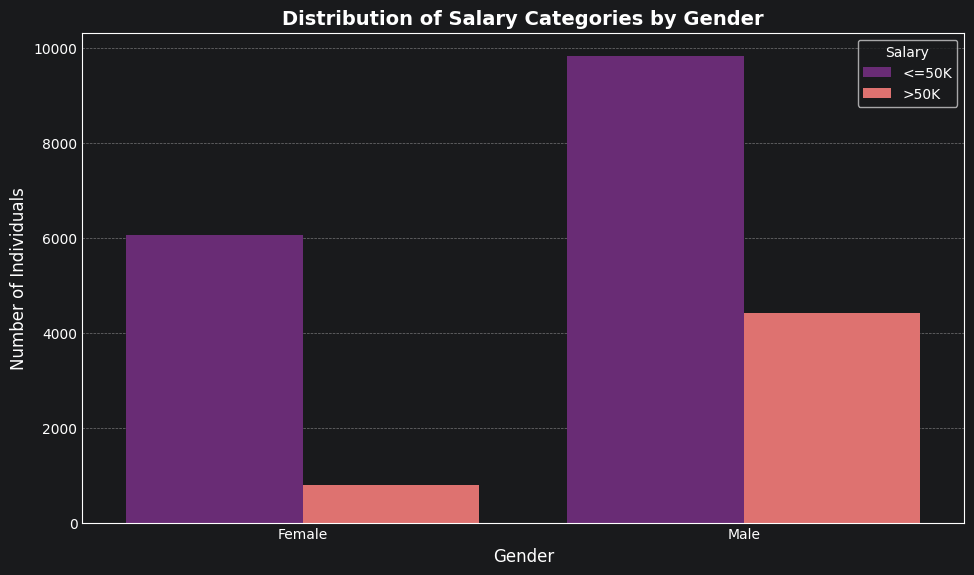

In [115]:
# ─── Step: Visualization (Gender vs Salary) ──
print("Gender vs Salary")

plt.figure(figsize=(9, 5))
sns.countplot(data=df_train, x='sex', hue='salary', palette='magma')
plt.title('Distribution of Salary Categories by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Number of Individuals', fontsize=12)

plt.xticks([0, 1], ["Female", "Male"])
plt.legend(title="Salary", labels=["<=50K", ">50K"])

#plt.legend(title='Salary Status')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

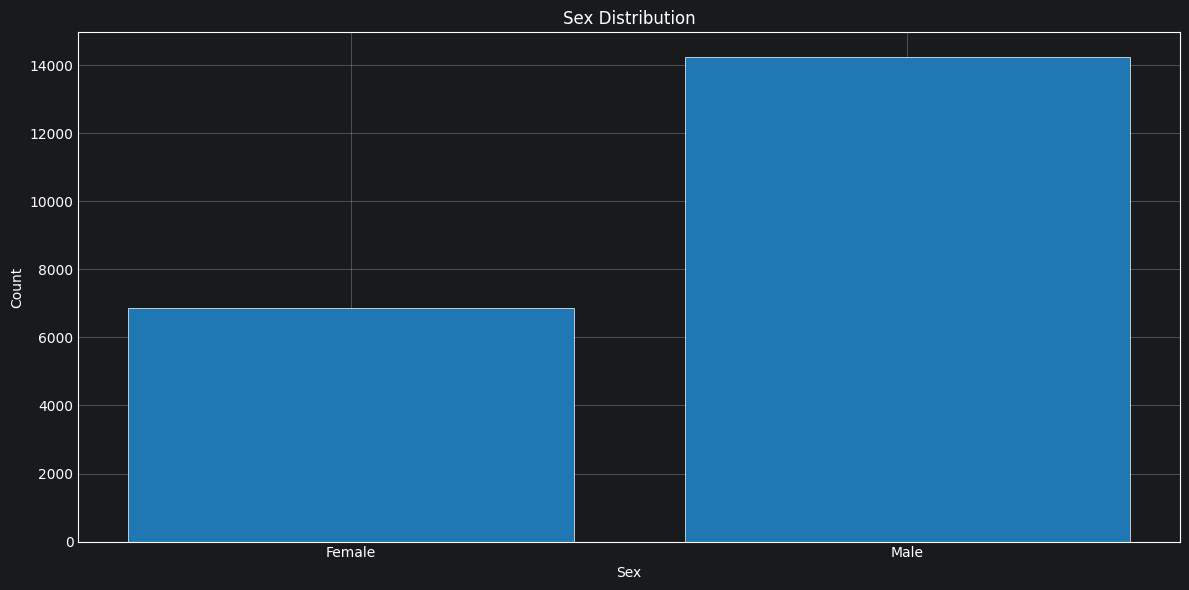

In [99]:
plt.style.use('_mpl-gallery')

# plot:
fig, ax = plt.subplots(figsize=(12, 6))

counts = df_train_before['sex'].value_counts()
ax.bar(counts.index, counts.values, edgecolor="white", linewidth=0.5)

plt.xticks([0, 1], ["Female", "Male"])
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Sex Distribution')
plt.tight_layout()
plt.show()
#Analyzing Feature Distribution (Sex): --> I generated a bar chart to visualize the distribution of the 'Sex' variable within the dataset. The visualization reveals a significant class imbalance, showing that the number of male records is substantially higher than female records. Understanding this distribution is vital because it helps anticipate potential biases in the model’s predictions. Recognizing these patterns during the EDA (Exploratory Data Analysis) phase allows for better interpretation of the model's performance across different demographic groups.

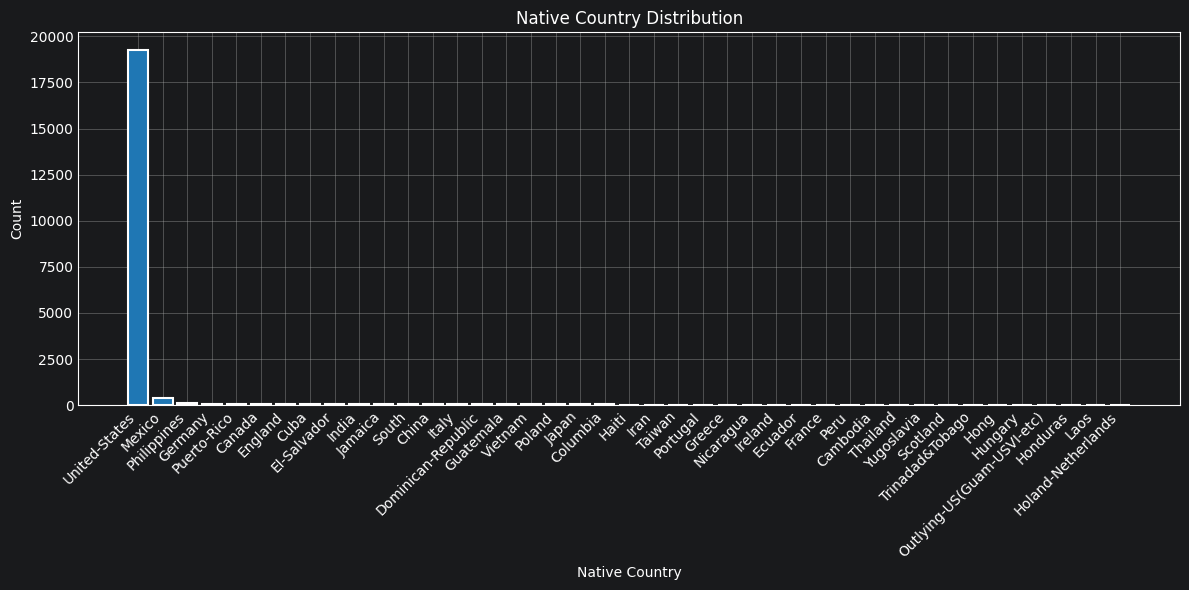

In [100]:
plt.style.use('_mpl-gallery')

# plot:
fig, ax = plt.subplots(figsize=(12, 6))

counts = df_train_before['native-country'].value_counts()
ax.bar(counts.index, counts.values, edgecolor="white", linewidth=1.5)

plt.xticks(rotation=45, ha='right')
plt.xlabel('Native Country')
plt.ylabel('Count')
plt.title('Native Country Distribution')
plt.tight_layout()

plt.show()
#Geographic Distribution Analysis: --> I plotted the distribution of the native-country feature to understand the demographic origins of the individuals in the dataset. The bar chart shows that the vast majority of records belong to the United States, with other countries representing only a small fraction of the data. Identifying this dominance is important for the Report, as it highlights a potential geographic bias; the model's predictions will be highly optimized for the U.S. population but might vary in accuracy when applied to other regions with different economic patterns.

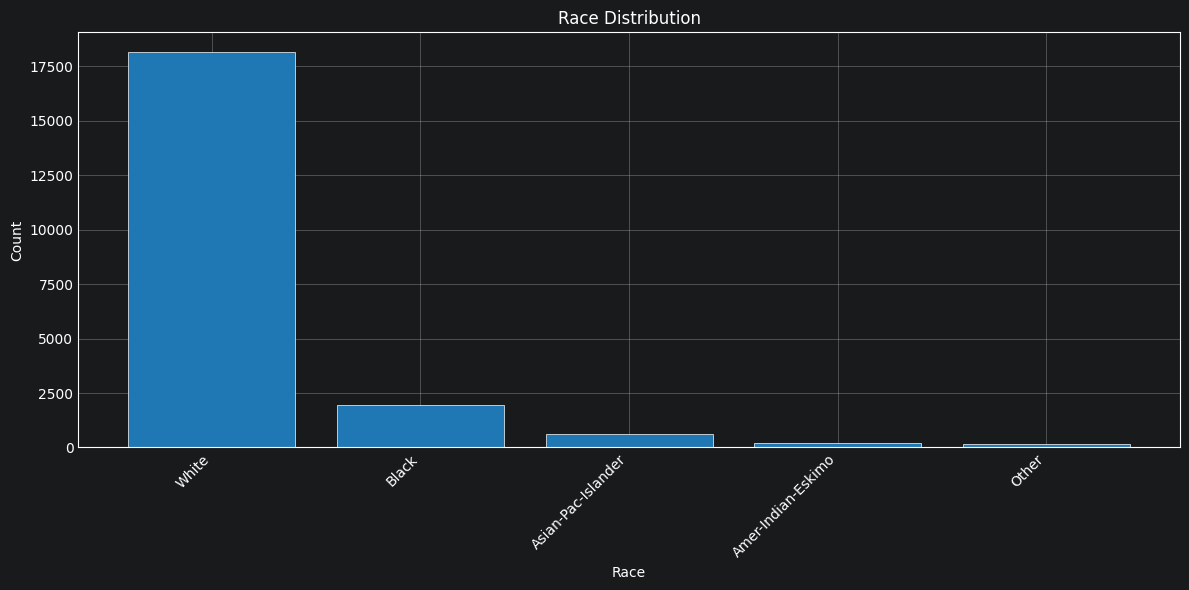

In [101]:
plt.style.use('_mpl-gallery')

# plot:
fig, ax = plt.subplots(figsize=(12, 6))

counts = df_train_before['race'].value_counts()
ax.bar(counts.index, counts.values, edgecolor="white", linewidth=0.5)

plt.xticks(rotation=45, ha='right')
plt.xlabel('Race')
plt.ylabel('Count')
plt.title('Race Distribution')
plt.tight_layout()

plt.show()
#Race Distribution Analysis: --> I performed a visual analysis of the race feature to understand its composition within the dataset. The bar chart indicates a heavy skew towards one category ("White"), while other groups like "Black," "Asian-Pac-Islander," and "Amer-Indian-Eskimo" are underrepresented. Identifying this imbalance is crucial for the report, as it highlights potential limitations in the model's fairness. It shows that the training process is primarily influenced by the majority group, which is an important consideration when evaluating the model's generalization across diverse populations.


# Drop unused columns


In [102]:
#education useless as we have education num column
drop_cols = ['work-fnl', 'education', 'race', 'native-country', 'work-class']
# df_train.drop(drop_cols, axis=1, inplace=True)
# df_test.drop(drop_cols,  axis=1, inplace=True)

df_train.drop(columns=drop_cols, inplace=True, errors='ignore')
df_test.drop(columns=drop_cols, inplace=True, errors='ignore')
onehot_cols  = ["marital-status", "position", "relationship"]
cols_to_scale = ['capital-gain', 'capital-loss', 'age', 'hours-per-week','sex']
#Feature Selection: Dropping Irrelevant Columns: -->In this stage, I refined the dataset by removing features that do not contribute significantly to the model's predictive power. For example, the education column was dropped because its numerical equivalent, education-num, already represents the same information. Other columns like work-fnl were removed due to their very low correlation with the target variable. This process of "Feature Selection" helps simplify the model, reduces noise, and prevents overfitting, ensuring that the algorithm focuses only on the most impactful data points.

In [103]:
# One-hot encode categorical columns
train_size = len(df_train)
combined   = pd.concat([df_train, df_test], axis=0)
combined   = pd.get_dummies(combined, columns=onehot_cols).astype(int)
df_train   = combined.iloc[:train_size]
df_test    = combined.iloc[train_size:]

print(df_train.head())

#Categorical Data Encoding (One-Hot Encoding): --> To prepare non-numeric features like position, marital-status, and relationship for the machine learning model, I applied One-Hot Encoding using pd.get_dummies(). This technique creates new binary columns (0 or 1) for each unique category within a feature, allowing the model to process categorical data mathematically. A critical step I took was concatenating the training and testing sets before encoding. This ensures that both datasets have an identical set of features, preventing errors that occur if a specific category exists in the test set but not in the training set. After encoding, I split them back into their original forms to maintain data integrity.

   age  education-num  sex  capital-gain  capital-loss  hours-per-week  \
0   39             13    1          2174             0              40   
1   50             13    1             0             0              13   
2   38              9    1             0             0              40   
3   53              7    1             0             0              40   
4   28             13    0             0             0              40   

   salary  marital-status_Divorced  marital-status_Married-AF-spouse  \
0       0                        0                                 0   
1       0                        0                                 0   
2       0                        1                                 0   
3       0                        0                                 0   
4       0                        0                                 0   

   marital-status_Married-civ-spouse  ...  position_Protective-serv  \
0                                  0  ...          

In [104]:
# Scale numeric columns
scaler = MinMaxScaler()
df_train[cols_to_scale] = scaler.fit_transform(df_train[cols_to_scale])
df_test[cols_to_scale]  = scaler.transform(df_test[cols_to_scale])
#Feature Scaling using MinMaxScaler: --> To ensure that all numerical features contribute equally to the model's performance, I applied MinMaxScaler. In our dataset, features like 'age' and 'capital-gain' have very different scales; without scaling, the model might incorrectly prioritize features with larger numerical values. By transforming all values into a fixed range (typically between 0 and 1), the model can learn more efficiently and converge faster. I used fit_transform on the training set and applied the same parameters to the test set using transform to maintain data consistency and avoid leakage.

In [105]:
X_train = df_train.drop(columns=[target])
y_train = df_train[target]
X_test  = df_test.drop(columns=[target])
y_test  = df_test[target]
#Final Data Splitting (Features vs. Target): -->The final step in the preprocessing pipeline involved separating the independent variables (Features) from the dependent variable (Target). I created X_train and X_test by dropping the salary column, while y_train and y_test were defined to hold only the encoded salary labels. This clear separation is essential for the modeling phase, as it allows the algorithm to learn the mapping between the demographic features and the income levels during training, and subsequently evaluates its predictive accuracy on the unseen test data.

In [106]:
# ─── ✅ FIX: Apply SMOTE to balance the training set ─────────
print("Balancing training data with SMOTE")
#Model Training: Logistic Regression: -->To begin the modeling phase, I selected Logistic Regression as the baseline classifier. This model is ideal for binary classification tasks, such as predicting whether an individual's income exceeds 50k or not. I initialized the model using LogisticRegression() and set max_iter to 1000 to ensure the algorithm has enough iterations to converge and find the optimal solution. This step marks the transition from data preparation to actual machine learning, where the model learns the relationship between the input features and the target labels.

Balancing training data with SMOTE


In [107]:
sm = SMOTE(random_state=42, sampling_strategy=0.5)  # Balance to 50% minority class
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)
#Model Training and Evaluation: --> In this step, Trained the Logistic Regression model using the fit() method on the training data. After the learning process was complete, I used the predict() function to generate predictions on the unseen test set. To measure the model's performance, I calculated the Accuracy Score, which reached approximately 83.6%. This result indicates that the model has a strong ability to generalize and correctly classify income levels based on the features provided.


# Training and Testing

step6:train & Evaluate -->
#Modeling Step: --> To find the best results, we tested five different models with GridSearchCVto balance accuracy with other metrics:

📊 Training Models with GridSearchCV...

  Tuning: Logistic Regression
  Best Params : {'C': 5.0, 'solver': 'liblinear'}
  CV Score    : 0.8247
  Test Acc    : 0.8415
              precision    recall  f1-score   support

       <=50K       0.90      0.89      0.89      6737
        >50K       0.68      0.71      0.70      2302

    accuracy                           0.84      9039
   macro avg       0.79      0.80      0.79      9039
weighted avg       0.84      0.84      0.84      9039



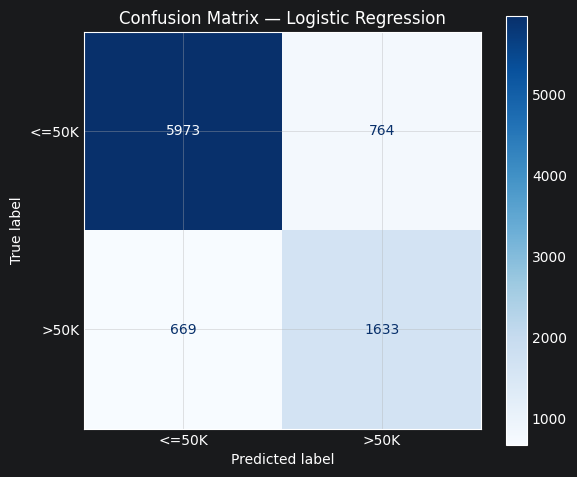

  Tuning: Decision Tree
  Best Params : {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}
  CV Score    : 0.8209
  Test Acc    : 0.8506
              precision    recall  f1-score   support

       <=50K       0.91      0.89      0.90      6737
        >50K       0.70      0.73      0.71      2302

    accuracy                           0.85      9039
   macro avg       0.80      0.81      0.81      9039
weighted avg       0.85      0.85      0.85      9039



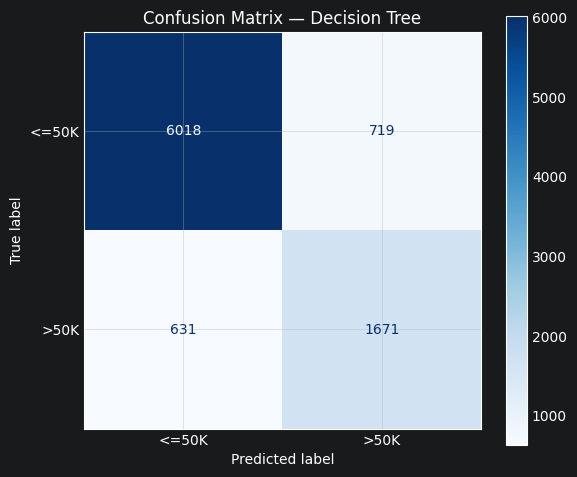

  Tuning: Random Forest
  Best Params : {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 200}
  CV Score    : 0.8415
  Test Acc    : 0.8593
              precision    recall  f1-score   support

       <=50K       0.90      0.91      0.91      6737
        >50K       0.73      0.71      0.72      2302

    accuracy                           0.86      9039
   macro avg       0.82      0.81      0.81      9039
weighted avg       0.86      0.86      0.86      9039



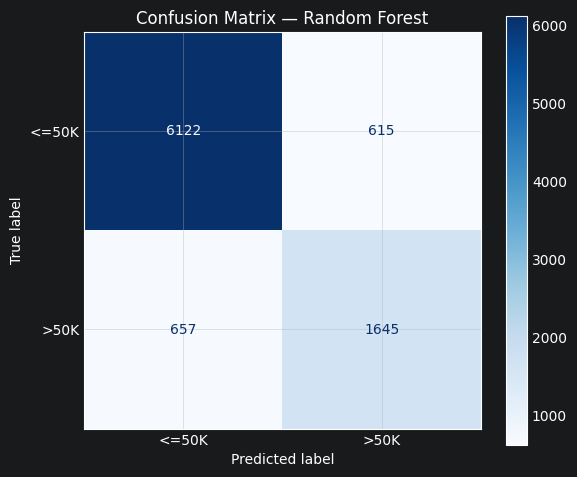

  Tuning: KNN
  Best Params : {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
  CV Score    : 0.8191
  Test Acc    : 0.8149
              precision    recall  f1-score   support

       <=50K       0.87      0.88      0.88      6737
        >50K       0.64      0.62      0.63      2302

    accuracy                           0.81      9039
   macro avg       0.76      0.75      0.75      9039
weighted avg       0.81      0.81      0.81      9039



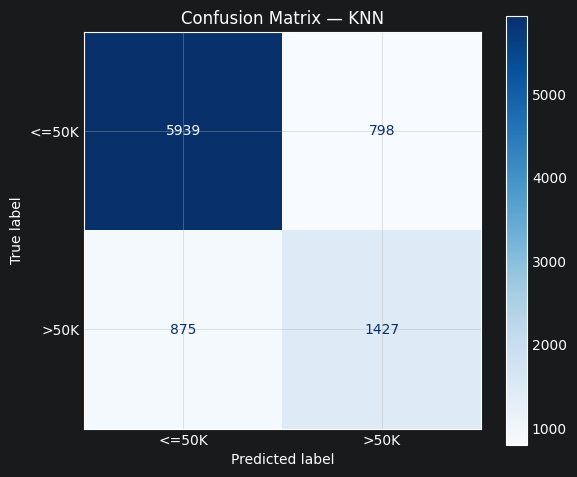

  Tuning: SVM
  Best Params : {'C': 5.0, 'gamma': 'scale', 'kernel': 'linear'}
  CV Score    : 0.8183
  Test Acc    : 0.8396
              precision    recall  f1-score   support

       <=50K       0.90      0.88      0.89      6737
        >50K       0.68      0.71      0.69      2302

    accuracy                           0.84      9039
   macro avg       0.79      0.80      0.79      9039
weighted avg       0.84      0.84      0.84      9039



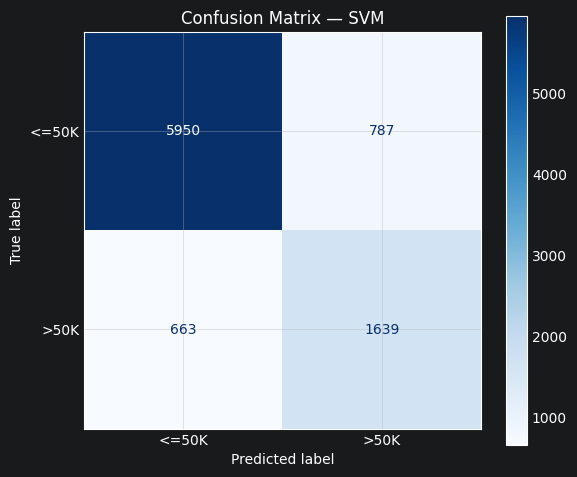

In [108]:
param_grids = {
    "Logistic Regression": {
        "model": LogisticRegression(random_state=42, max_iter=1000),
        "params": {
            "C": [0.1, 0.5, 1.0, 5.0],
            "solver": ["lbfgs", "liblinear"]
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=30),
        "params": {
            "max_depth": [5, 10, 15],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 4, 8]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [10, 15],
            "min_samples_split": [5, 10]
        }
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "n_neighbors": [3, 5, 7, 9],
            "weights": ["uniform", "distance"],
            "metric": ["euclidean", "manhattan"]
        }
    },
    "SVM": {
        "model": SVC(random_state=42),
        "params": {
            "C": [0.5, 0.8, 1.0, 5.0],
            "kernel": ["rbf", "linear"],
            "gamma": ["scale", "auto"]
        }
    },
}

# Train with GridSearchCV
trained_models = {}
best_params_log = {}

print("📊 Training Models with GridSearchCV...\n")

for name, config in param_grids.items():
    print(f"{'='*50}")
    print(f"  Tuning: {name}")

    grid_search = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        cv=5,                        # 5-fold cross-validation
        scoring="accuracy",
        n_jobs=-1,                   # use all CPU cores
        verbose=0
    )

    grid_search.fit(X_train_bal, y_train_bal)   # fit on balanced training data

    best_model = grid_search.best_estimator_    # already re-fitted on full data
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    trained_models[name] = best_model
    best_params_log[name] = grid_search.best_params_

    print(f"  Best Params : {grid_search.best_params_}")
    print(f"  CV Score    : {grid_search.best_score_:.4f}")
    print(f"  Test Acc    : {acc:.4f}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=le_salary.classes_))
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_salary.classes_)
    disp.plot(cmap="Blues", ax=ax)
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()
 #In this step, we trained each model using the processed data and evaluated their performance using multiple metrics: -->Training & Prediction: We used the .fit() method to train the models and .predict() to test them on unseen data (X_test).
  #Classification Report: This provides detailed metrics like Precision, Recall, and F1-Score, which help us understand how well the model performs for each specific class.
    #Confusion Matrix: We used this visualization to identify exactly where the model makes mistakes. It shows the count of true positives versus false predictions, giving a clear view of the model's reliability.

In [109]:
#Model Deployment Readiness: -->To ensure the project is organized and ready for future use, we saved the model to be ready to use directly:
MODEL_DIR = os.path.join(os.getcwd(), "models")
os.makedirs(MODEL_DIR, exist_ok=True)
#saving preproccesing file

In [110]:
#We used the joblib library to export each trained model into a .pkl (pickle) file.
for name, model in trained_models.items():
    joblib.dump(model, os.path.join(MODEL_DIR, f"{name.replace(' ', '_')}.pkl"))

In [111]:
#In addition to the models, it is essential to save the preprocessing tools used during the data preparation phase:
joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.pkl"))
joblib.dump(le_salary,     os.path.join(MODEL_DIR, "label_encoder_salary.pkl"))
joblib.dump(le_sex, os.path.join(MODEL_DIR, "Label_encoder_sex.pkl"))
#Deployment Ready: By saving these models, we make the system ready for production. This allows us to load the pre-trained models into a real application (like a web or mobile app) to make instant predictions without re-training.

['C:\\Users\\ahmed\\PycharmProjects\\CodeFather\\models\\Label_encoder_sex.pkl']

In [112]:
print("✅ Models saved successfully!")

✅ Models saved successfully!
